In [19]:
from collections import defaultdict
import glob
import numpy as np
import matplotlib.pyplot as plt
from pyubx2 import UBXReader
from pyubx2 import UBX_PROTOCOL, NMEA_PROTOCOL, RTCM3_PROTOCOL

In [20]:
MS_TO_METERS = 299_792_458.0 / 1_000

CONSTELLATION_MAP = {
    "1077": "GPS",
    "1127": "BDS",
}

ACCEPTED_SIGNALS = {
    "1077": {"1C"},
    "1127": {"2I, 1X"},
}

In [21]:
sampleFiles = glob.glob("samples/*.rtcm")
sampleFiles[0]

'samples/pushpull-260430-181825.rtcm'

In [22]:
with open(sampleFiles[0], 'rb') as stream:
    reader = UBXReader(
        stream, 
        protfilter=RTCM3_PROTOCOL | UBX_PROTOCOL | NMEA_PROTOCOL
    )

    for i, (raw_data, parsed_data) in enumerate(reader):
        print(f"Parsed data: {parsed_data}")
        if parsed_data is not None:
            if i > 10:
                break
            print(f"Message type: {parsed_data.identity}")

Parsed data: <UBX(NAV-SAT, iTOW=23:18:15.600000, version=1, numSvs=39, reserved0=0, gnssId_01=GPS, svId_01=10, cno_01=36, elev_01=34, azim_01=286, prRes_01=-1.7, qualityInd_01=7, svUsed_01=1, health_01=1, diffCorr_01=1, smoothed_01=0, orbitSource_01=1, ephAvail_01=1, almAvail_01=1, anoAvail_01=0, aopAvail_01=0, sbasCorrUsed_01=1, rtcmCorrUsed_01=0, slasCorrUsed_01=0, spartnCorrUsed_01=0, prCorrUsed_01=1, crCorrUsed_01=0, doCorrUsed_01=1, clasCorrUsed_01=0, lppCorrUsed_01=0, hasCorrUsed_01=0, gnssId_02=GPS, svId_02=15, cno_02=41, elev_02=39, azim_02=44, prRes_02=1.2, qualityInd_02=7, svUsed_02=1, health_02=1, diffCorr_02=1, smoothed_02=0, orbitSource_02=1, ephAvail_02=1, almAvail_02=1, anoAvail_02=0, aopAvail_02=0, sbasCorrUsed_02=1, rtcmCorrUsed_02=0, slasCorrUsed_02=0, spartnCorrUsed_02=0, prCorrUsed_02=1, crCorrUsed_02=0, doCorrUsed_02=1, clasCorrUsed_02=0, lppCorrUsed_02=0, hasCorrUsed_02=0, gnssId_03=GPS, svId_03=18, cno_03=41, elev_03=78, azim_03=60, prRes_03=-0.4, qualityInd_03=7

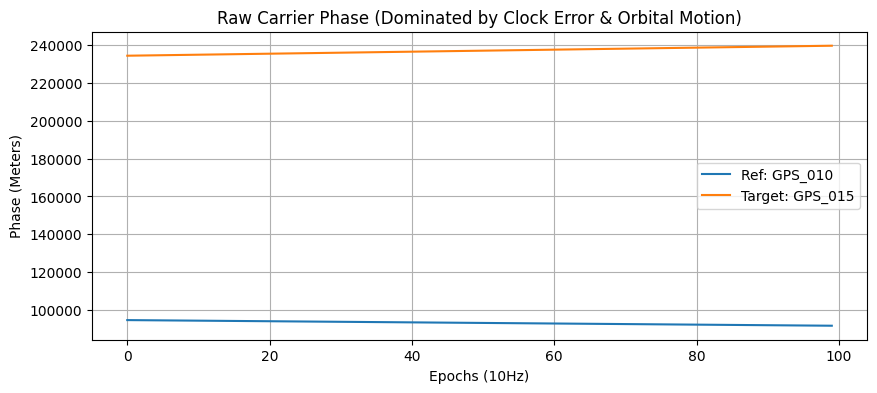

In [23]:
filepath = glob.glob("samples/*.rtcm")[0]

phases = defaultdict(list)

with open(sampleFiles[0], 'rb') as f:
    ubr = UBXReader(f)
    for _raw, parsed in ubr:
        if parsed is None:
            continue
        
        mid = parsed.identity
        if mid in CONSTELLATION_MAP:
            nSat = getattr(parsed, "NSat", 0)
            nCell = getattr(parsed, "NCell", 0)

            if nSat == 0 or nCell == 0:
                continue

            rough = {
                getattr(parsed, f"PRN_{s:02d}"): getattr(parsed, f"DF398_{s:02d}")
                for s in range(1, nSat + 1) if getattr(parsed, f"PRN_{s:02d}", None)
            }

            for c in range(1, nCell + 1):
                prn = getattr(parsed, f"CELLPRN_{c:02d}", None)
                sig = getattr(parsed, f"CELLSIG_{c:02d}", None)
                fpr = getattr(parsed, f"DF406_{c:02d}", None)
                
                if prn and fpr and prn in rough and sig in ACCEPTED_SIGNALS[mid]:
                    key = f"{CONSTELLATION_MAP[mid]}_{int(prn):03d}"
                    phases[key].append((rough[prn] + fpr) * MS_TO_METERS)
# Find satellites with a full 100 epochs
good_sats = [k for k, v in phases.items() if len(v) == 100]
# Pick two arbitrary healthy satellites to look at
ref_sat = good_sats[0]
tgt_sat = good_sats[1]
plt.figure(figsize=(10, 4))
plt.plot(phases[ref_sat][:100], label=f"Ref: {ref_sat}")
plt.plot(phases[tgt_sat][:100], label=f"Target: {tgt_sat}")
plt.title("Raw Carrier Phase (Dominated by Clock Error & Orbital Motion)")
plt.ylabel("Phase (Meters)")
plt.xlabel("Epochs (10Hz)")
plt.legend()
plt.grid(True)
plt.show()

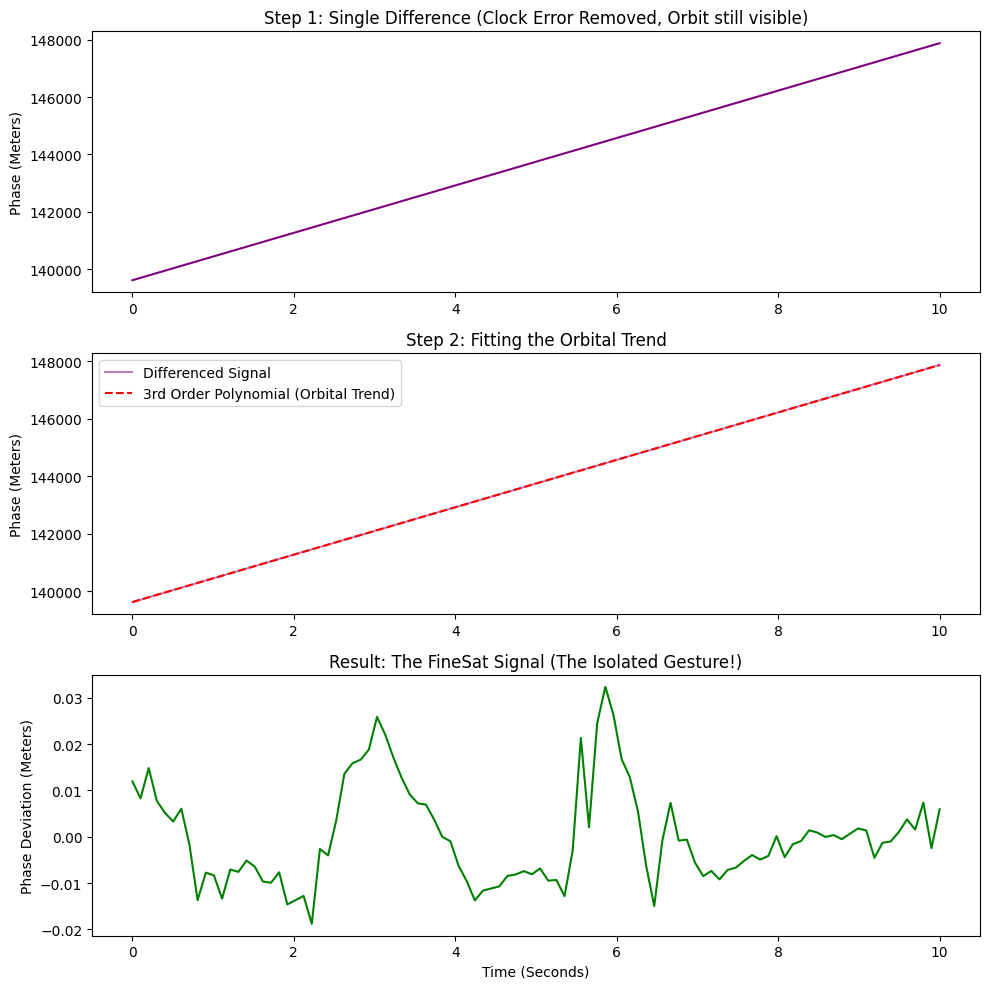

In [24]:
import numpy as np
# 1. Convert to numpy arrays
ref_signal = np.array(phases[ref_sat][:100])
tgt_signal = np.array(phases[tgt_sat][:100])
# Time array (100 epochs over 10 seconds)
t = np.linspace(0, 10, 100)
# 2. Step 1: Single Difference (Removes Clock Error)
diff_signal = tgt_signal - ref_signal
# 3. Step 2: 3rd-Order Polynomial Detrending (Removes Orbital Motion)
# Fit the curve
poly_coeffs = np.polyfit(t, diff_signal, 3)
trend = np.polyval(poly_coeffs, t)
# Subtract the curve to isolate the gesture!
finesat_signal = diff_signal - trend
# Plotting the progression
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
# Plot A: The Single Difference
axs[0].plot(t, diff_signal, color='purple')
axs[0].set_title("Step 1: Single Difference (Clock Error Removed, Orbit still visible)")
axs[0].set_ylabel("Phase (Meters)")
# Plot B: The Orbit Trend
axs[1].plot(t, diff_signal, label="Differenced Signal", alpha=0.5, color='purple')
axs[1].plot(t, trend, label="3rd Order Polynomial (Orbital Trend)", color='red', linestyle='--')
axs[1].set_title("Step 2: Fitting the Orbital Trend")
axs[1].set_ylabel("Phase (Meters)")
axs[1].legend()
# Plot C: The FineSat Signal (The Gesture!)
axs[2].plot(t, finesat_signal, color='green')
axs[2].set_title("Result: The FineSat Signal (The Isolated Gesture!)")
axs[2].set_ylabel("Phase Deviation (Meters)")
axs[2].set_xlabel("Time (Seconds)")
plt.tight_layout()
plt.show()